In [31]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
from skimage.metrics import structural_similarity as ssim
from collections import Counter
import heapq
import pandas as pd
from tqdm import tqdm

In [13]:
test_data_folder = Path("test_data")

def load_data(folder) -> list:
    data_rgb = []

    for file in folder.glob("*.png"):
        image = Image.open(file).convert("RGB")
        data_rgb.append(image.copy())
        image.close()

    print("Count of loaded .png images:", len(data_rgb))
    return data_rgb

loaded_data_rgb = load_data(test_data_folder)


Count of loaded .png images: 71


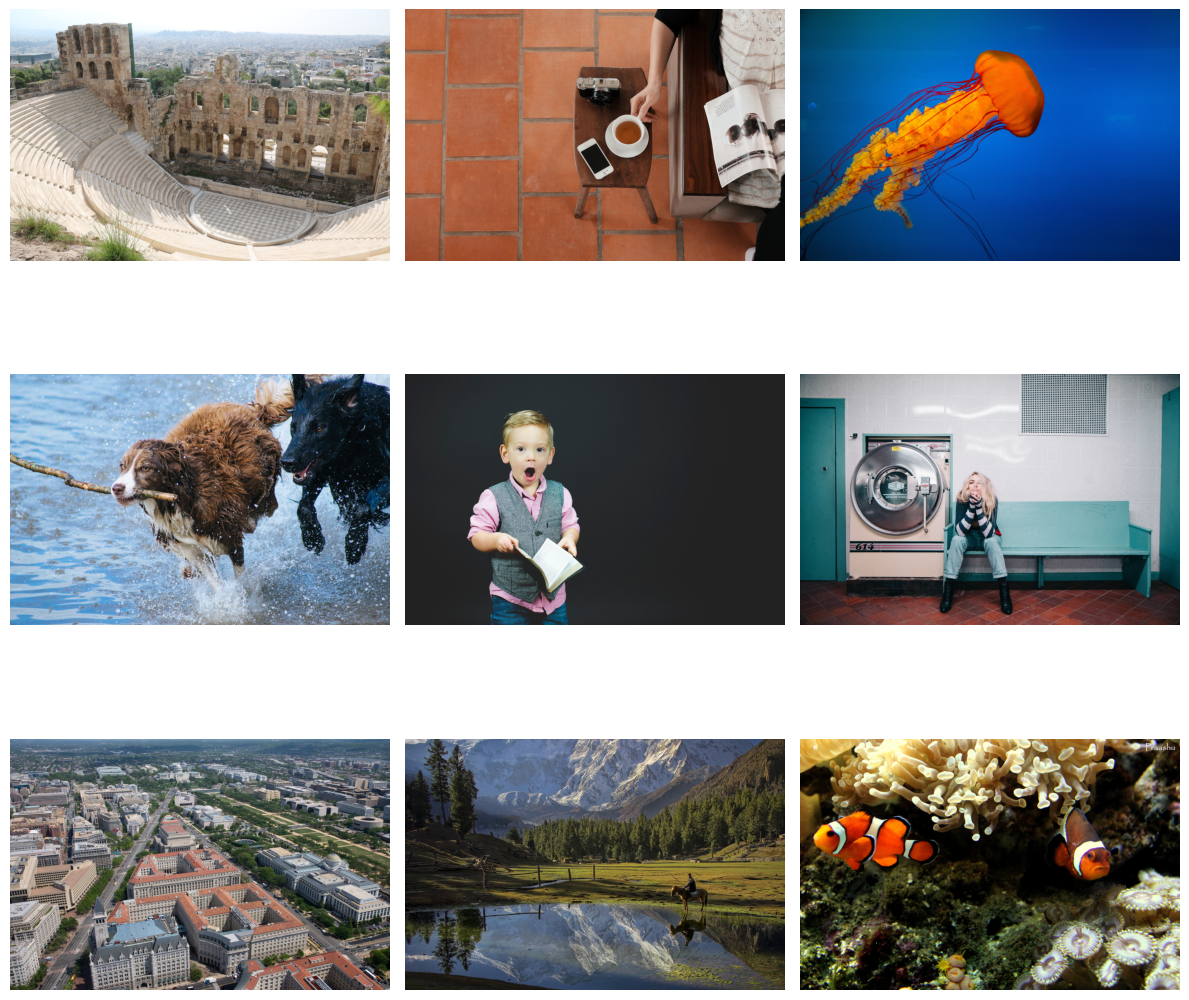

In [14]:
def plot_image_examples(images, n_rows=3, n_cols=3, start_idx=10, title="Example images"):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.ravel()

    for ax_idx, ax in enumerate(axes):
        img_idx = start_idx + ax_idx

        if img_idx < len(images):
            img = images[img_idx].convert("RGB")
            ax.imshow(img)
        else:
            ax.set_visible(False)

        ax.axis("off")

    plt.tight_layout()
    plt.show()      

plot_image_examples(loaded_data_rgb)

In [15]:
class JPEGCodec:
    def __init__(self, block_size: int = 8, q_y: int = 10, q_c: int = 16):
        self.N = block_size
        self.C = self._dct_matrix(block_size)
        self.q_y = q_y
        self.q_c = q_c

    def _dct_matrix(self, N: int) -> np.ndarray:
        C = np.zeros((N, N), dtype=np.float64)
        for i in range(N):
            for j in range(N):
                alpha = np.sqrt(1 / N) if i == 0 else np.sqrt(2 / N)
                C[i, j] = alpha * np.cos(((2 * j + 1) * i * np.pi) / (2 * N))
        return C
    
    def _split_blocks(self, channel):
        H, W = channel.shape
        assert H % self.N == 0 and W % self.N == 0, "Image dimensions must be divisible by block size"
        return channel.reshape(
            H // self.N, self.N,
            W // self.N, self.N
        ).transpose(0, 2, 1, 3)

    def _merge_blocks(self, blocks):
        nb_h, nb_w, bh, bw = blocks.shape
        return blocks.transpose(0, 2, 1, 3).reshape(nb_h * bh, nb_w * bw)
    
    def _dct2(self, block):
        return self.C @ block @ self.C.T
    
    def _idct2(self, block):
        return self.C.T @ block @ self.C
    
    def transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._dct2(blocks[i, j])
        return out
    
    def inverse_transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._idct2(blocks[i, j])
        return out
    
    
    def transform(self, image: Image.Image) -> dict:
        image = image.convert("YCbCr")
        arr = np.asarray(image, dtype=np.uint8).astype(np.float64) - 128.0
        channels = []

        for c in range(3):
            blocks = self._split_blocks(arr[:, :, c])
            dct_blocks = self.transform_blocks(blocks)
            channels.append(dct_blocks)

        return {
            "ch1": channels[0],
            "ch2": channels[1],
            "ch3": channels[2]
        }

    def inverse_transform(self, encoded: dict) -> Image.Image:
        rec_channels = []

        for key in ["ch1", "ch2", "ch3"]:
            blocks = self.inverse_transform_blocks(encoded[key])
            rec_channels.append(self._merge_blocks(blocks))
        
        rec = np.stack(rec_channels, axis=-1)
        return Image.fromarray(np.clip(rec + 128.0, 0, 255).astype(np.uint8), mode="YCbCr").convert("RGB")
    

    # Quantization
    def quantize(self, transformed: dict) -> dict:
        quantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            quantized[key] = np.round(transformed[key] / q).astype(np.int32)
        return quantized
    
    def dequantize(self, quantized: dict) -> dict:
        dequantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            dequantized[key] = (quantized[key] * q).astype(np.float64)
        return dequantized
    
    # Zigzag scan
    def _zigzag_indices(self, N: int) -> np.ndarray:
        indices = []

        for s in range(2 * N - 1):
            if s % 2 == 0:
                for i in range(s, -1, -1):
                    j = s - i
                    if i < N and j < N:
                        indices.append((i, j))
            else:
                for j in range(s, -1, -1):
                    i = s - j
                    if i < N and j < N:
                        indices.append((i, j))
        return np.array(indices)
    
    def zigzag_scan(self, block):
        return np.array([block[i, j] for i, j in self._zigzag_indices(self.N)], dtype=np.int32)
    
    def zigzag_unscan(self, arr):
        block = np.zeros((self.N, self.N), dtype=np.int32)

        for idx, (i, j) in enumerate(self._zigzag_indices(self.N)):
            block[i, j] = arr[idx]
        return block
    
    # DC - DPCM
    def DPCM_encode(self, dc_values) -> np.ndarray:
        dc_values = np.asarray(dc_values, dtype=np.int32)

        diffs = np.empty_like(dc_values)
        previous = 0

        for i, dc in enumerate(dc_values):
            diffs[i] = dc - previous
            previous = dc

        return diffs
    
    def DPCM_decode(self, dc_diffs) -> np.ndarray:
        dc_diffs = np.asarray(dc_diffs, dtype=np.int32)

        dc_values = np.empty_like(dc_diffs)
        previous = 0

        for i, diff in enumerate(dc_diffs):
            dc_values[i] = diff + previous
            previous = dc_values[i]

        return dc_values
    
    # AC Run-length coding
    def RL_encode(self, arr):
        arr = np.asarray(arr, dtype=np.int32)
        symbols = []
        zero_run = 0

        for value in arr:
            value = int(value)

            if value == 0:
                zero_run += 1
            else:
                symbols.append((zero_run, value))
                zero_run = 0

        symbols.append(("EOB",))
        return symbols
    
    def RL_decode(self, symbols):
        ac = []
        for symbol in symbols:
            if symbol[0] == "EOB":
                break

            zero_run, value = symbol
            ac.extend([0] * zero_run)
            ac.append(value)

        target_length = self.N * self.N - 1
        ac.extend([0] * (target_length - len(ac)))
        return np.array(ac[:target_length], dtype=np.int32)

    # Entropy coding
    def entropy_encode(self, q_blocks):
        dc_values = []
        ac_symbols = []

        for i in range(q_blocks.shape[0]):
            for j in range(q_blocks.shape[1]):
                zz = self.zigzag_scan(q_blocks[i, j])

                dc_values.append(int(zz[0]))
                ac_symbols.append(self.RL_encode(zz[1:]))
        dc_diffs = self.DPCM_encode(dc_values)
        return {"dc_diffs": dc_diffs, "ac_symbols": ac_symbols, "shape": q_blocks.shape}

    def entropy_decode(self, encoded):
        nb_h, nb_w, _, _ = encoded["shape"]
        dc_values = self.DPCM_decode(encoded["dc_diffs"])
        ac_symbols = encoded["ac_symbols"]

        blocks = np.empty((nb_h, nb_w, self.N, self.N), dtype=np.int32)

        k = 0
        for i in range(nb_h):
            for j in range(nb_w):
                dc = dc_values[k]
                ac = self.RL_decode(ac_symbols[k])

                zz = np.concatenate(([dc], ac))
                blocks[i, j] = self.zigzag_unscan(zz)
                k += 1

        return blocks

    def encode(self, image: Image.Image) -> dict:
        transformed = self.transform(image)
        quantized = self.quantize(transformed)
        entropy_encoded = {key: self.entropy_encode(quantized[key]) for key in ["ch1", "ch2", "ch3"]}
        return entropy_encoded
    
    def decode(self, encoded: dict) -> Image.Image:
        entropy_decoded = {key: self.entropy_decode(encoded[key]) for key in ["ch1", "ch2", "ch3"]}
        dequantized = self.dequantize(entropy_decoded)
        output = self.inverse_transform(dequantized)
        return output

In [32]:
def MSE(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    mse = np.mean((arr_orig - arr_rec) ** 2)
    return mse

def PSNR(original: Image.Image, reconstructed: Image.Image) -> float:
    mse = MSE(original, reconstructed)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * np.log10(max_pixel**2 / mse)
    return psnr

def SSIM(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    ssim_value = ssim(arr_orig, arr_rec, multichannel=True, channel_axis=2,data_range=255)
    return ssim_value

def entropy_symbols(symbols):
    counts = Counter(symbols)
    total = sum(counts.values())

    probs = np.array([count / total for count in counts.values()])
    return -np.sum(probs * np.log2(probs))


class HuffmanNode:
    def __init__(self, left=None, right=None):
        self.left = left
        self.right = right

def flatten_symbols(encoded):
    all_dc = []
    all_ac = []

    for key in ["ch1", "ch2", "ch3"]:
        all_dc.extend(encoded[key]["dc_diffs"].tolist())

        for block_symbols in encoded[key]["ac_symbols"]:
            all_ac.extend(block_symbols)

    return all_dc, all_ac

def build_huffman_codebook(symbols):
    counts = Counter(symbols)

    if len(counts) == 1:
        only_symbol = next(iter(counts))
        return {only_symbol: "0"}

    heap = []
    counter = 0

    for symbol, freq in counts.items():
        heapq.heappush(heap, (freq, counter, symbol))
        counter += 1

    while len(heap) > 1:
        freq1, _, left = heapq.heappop(heap)
        freq2, _, right = heapq.heappop(heap)

        node = HuffmanNode(left, right)
        heapq.heappush(heap, (freq1 + freq2, counter, node))
        counter += 1

    root = heap[0][2]
    codebook = {}

    def assign_codes(node, prefix):
        if isinstance(node, HuffmanNode):
            assign_codes(node.left, prefix + "0")
            assign_codes(node.right, prefix + "1")
        else:
            codebook[node] = prefix

    assign_codes(root, "")
    return codebook

def huffman_length(symbols, codebook):
    return sum(len(codebook[s]) for s in symbols)



In [17]:
def performance_single_image(image: Image.Image, codec) -> dict:
    image = image.convert("RGB")

    encoded = codec.encode(image)
    reconstructed = codec.decode(encoded)

    mse_value = MSE(image, reconstructed)
    psnr_value = PSNR(image, reconstructed)
    ssim_value = SSIM(image, reconstructed)

    all_dc, all_ac = flatten_symbols(encoded)

    dc_codebook = build_huffman_codebook(all_dc)
    ac_codebook = build_huffman_codebook(all_ac)

    L_dc = huffman_length(all_dc, dc_codebook)
    L_ac = huffman_length(all_ac, ac_codebook)
    L_total = L_dc + L_ac

    W, H = image.size
    num_pixels = W * H

    bpp = L_total / num_pixels
    original_bpp = 24
    compression_ratio = original_bpp / bpp

    H_dc = entropy_symbols(all_dc)
    H_ac = entropy_symbols(all_ac)

    entropy_bits_est = H_dc * len(all_dc) + H_ac * len(all_ac)
    entropy_bpp_est = entropy_bits_est / num_pixels

    return {
        "mse": mse_value,
        "psnr": psnr_value,
        "ssim": ssim_value,
        "L_dc_bits": L_dc,
        "L_ac_bits": L_ac,
        "L_total_bits": L_total,
        "bpp": bpp,
        "compression_ratio": compression_ratio,
        "entropy_dc": H_dc,
        "entropy_ac": H_ac,
        "entropy_bpp_est": entropy_bpp_est,
        "num_dc_symbols": len(all_dc),
        "num_ac_symbols": len(all_ac),
    }

def evaluate_q_values(images, q_y_values, block_size=8, chroma_factor=1.6):
    rows = []

    for q_y in q_y_values:
        q_c = q_y * chroma_factor

        for image_idx, image in tqdm(enumerate(images), total=len(images), desc=f"q_y={q_y}, q_c={q_c}"):
            codec = JPEGCodec(
                block_size=block_size,
                q_y=q_y,
                q_c=q_c
            )

            metrics = performance_single_image(image, codec)

            metrics["image_idx"] = image_idx
            metrics["q_y"] = q_y
            metrics["q_c"] = q_c

            rows.append(metrics)

        print(f"Finished q_y={q_y}, q_c={q_c}")

    df_all = pd.DataFrame(rows)

    df_mean = (
        df_all
        .groupby(["q_y", "q_c"])
        .agg(
            mse_mean=("mse", "mean"),
            mse_std=("mse", "std"),
            psnr_mean=("psnr", "mean"),
            psnr_std=("psnr", "std"),
            ssim_mean=("ssim", "mean"),
            ssim_std=("ssim", "std"),
            bpp_mean=("bpp", "mean"),
            bpp_std=("bpp", "std"),
            compression_ratio_mean=("compression_ratio", "mean"),
            compression_ratio_std=("compression_ratio", "std"),
            L_total_bits_mean=("L_total_bits", "mean"),
            entropy_bpp_mean=("entropy_bpp_est", "mean"),
        )
        .reset_index()
    )

    return df_all, df_mean

In [18]:
# Load data
df_all = pd.read_csv("performance/df_all_results.csv")
df_mean = pd.read_csv("performance/df_mean_results.csv")

In [19]:
display(df_mean)
q_y_values = df_mean["q_y"].unique()
mse_mean = df_mean["mse_mean"].values
mse_std = df_mean["mse_std"].values
psnr_mean = df_mean["psnr_mean"].values
psnr_std = df_mean["psnr_std"].values
ssim_mean = df_mean["ssim_mean"].values
ssim_std = df_mean["ssim_std"].values
bpp_mean = df_mean["bpp_mean"].values
bpp_std = df_mean["bpp_std"].values
compression_ratio_mean = df_mean["compression_ratio_mean"].values
compression_ratio_std = df_mean["compression_ratio_std"].values
L_total_bits_mean = df_mean["L_total_bits_mean"].values
entropy_bpp_mean = df_mean["entropy_bpp_mean"].values


,q_y,q_c,mse_mean,mse_std,psnr_mean,psnr_std,ssim_mean,ssim_std,bpp_mean,bpp_std,compression_ratio_mean,compression_ratio_std,L_total_bits_mean,entropy_bpp_mean
0,1,1.6,6.408370,0.985301,40.174260,1.250942,0.987376,0.012501,7.983967,2.085670,3.214117,0.872958,2.180428e+07,7.946166
1,2,3.2,6.903068,1.058959,39.845598,1.202625,0.985616,0.011843,5.366261,1.753916,4.946186,1.645205,1.465530e+07,5.339043
2,3,4.8,7.739339,1.201488,39.338803,1.101783,0.982548,0.011713,4.204049,1.536181,6.487768,2.489404,1.148129e+07,4.180736
3,4,6.4,8.574725,1.480691,38.894418,1.047287,0.979059,0.012025,3.509005,1.374758,7.952268,3.383421,9.583120e+06,3.488062
4,5,8.0,8.909404,1.957547,38.757872,1.123916,0.976064,0.011538,3.032776,1.246459,9.363165,4.245236,8.282535e+06,3.014323
5,10,16.0,14.610363,4.404387,36.678863,1.323067,0.956530,0.018378,1.864486,0.872414,16.084849,8.344080,5.091927e+06,1.851013
6,20,32.0,29.255416,11.329333,33.784892,1.691008,0.920590,0.026600,1.092244,0.554822,28.515953,16.128141,2.982926e+06,1.081583
7,30,48.0,46.352716,19.315005,31.828684,1.795069,0.889185,0.032021,0.778613,0.404055,39.990897,21.939988,2.126399e+06,0.768838
8,40,64.0,64.502063,28.049865,30.423258,1.867942,0.861533,0.037303,0.605278,0.313938,50.931898,26.647982,1.653019e+06,0.594264
9,50,80.0,83.934662,36.792366,29.278875,1.856136,0.834369,0.042541,0.494263,0.253899,61.456947,30.348363,1.349837e+06,0.481709


In [20]:
import matplotlib.pyplot as plt


def plot_reconstruction_quality(
    q_y_values,
    mse_mean, mse_std,
    psnr_mean, psnr_std,
    ssim_mean, ssim_std,
    save_path=None
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].errorbar(q_y_values, mse_mean, yerr=mse_std, marker="o", capsize=4)
    axes[0].set_xlabel(r"Quantization step size $q_y$")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("MSE vs Quantization Strength")
    axes[0].set_xscale("log")
    axes[0].grid(True)

    axes[1].errorbar(q_y_values, psnr_mean, yerr=psnr_std, marker="o", capsize=4)
    axes[1].set_xlabel(r"Quantization step size $q_y$")
    axes[1].set_ylabel("PSNR (dB)")
    axes[1].set_title("PSNR vs Quantization Strength")
    axes[1].set_xscale("log")
    axes[1].grid(True)

    axes[2].errorbar(q_y_values, ssim_mean, yerr=ssim_std, marker="o", capsize=4)
    axes[2].set_xlabel(r"Quantization step size $q_y$")
    axes[2].set_ylabel("SSIM")
    axes[2].set_title("SSIM vs Quantization Strength")
    axes[2].set_xscale("log")
    axes[2].grid(True)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
def plot_compression_effect(
    q_y_values,
    bpp_mean, bpp_std,
    compression_ratio_mean, compression_ratio_std,
    L_total_bits_mean,
    entropy_bpp_mean,
    save_path=None
):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()

    axes[0].errorbar(
        q_y_values,
        bpp_mean,
        yerr=bpp_std,
        marker="o",
        capsize=4
    )
    axes[0].set_xlabel(r"Quantization step size $q_y$")
    axes[0].set_ylabel("Bits per pixel")
    axes[0].set_title("BPP vs Quantization Strength")
    axes[0].set_xscale("log")
    axes[0].grid(True)

    axes[1].errorbar(
        q_y_values,
        compression_ratio_mean,
        yerr=compression_ratio_std,
        marker="o",
        capsize=4
    )
    axes[1].set_xlabel(r"Quantization step size $q_y$")
    axes[1].set_ylabel("Compression ratio")
    axes[1].set_title("Compression Ratio vs Quantization Strength")
    axes[1].set_xscale("log")
    axes[1].grid(True)

    axes[2].plot(
        q_y_values,
        L_total_bits_mean,
        marker="o"
    )
    axes[2].set_xlabel(r"Quantization step size $q_y$")
    axes[2].set_ylabel("Total code length [bits]")
    axes[2].set_title("Code Length vs Quantization Strength")
    axes[2].set_xscale("log")
    axes[2].grid(True)

    axes[3].plot(
        q_y_values,
        entropy_bpp_mean,
        marker="o"
    )
    axes[3].set_xlabel(r"Quantization step size $q_y$")
    axes[3].set_ylabel("Entropy estimate [bpp]")
    axes[3].set_title("Entropy BPP vs Quantization Strength")
    axes[3].set_xscale("log")
    axes[3].grid(True)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

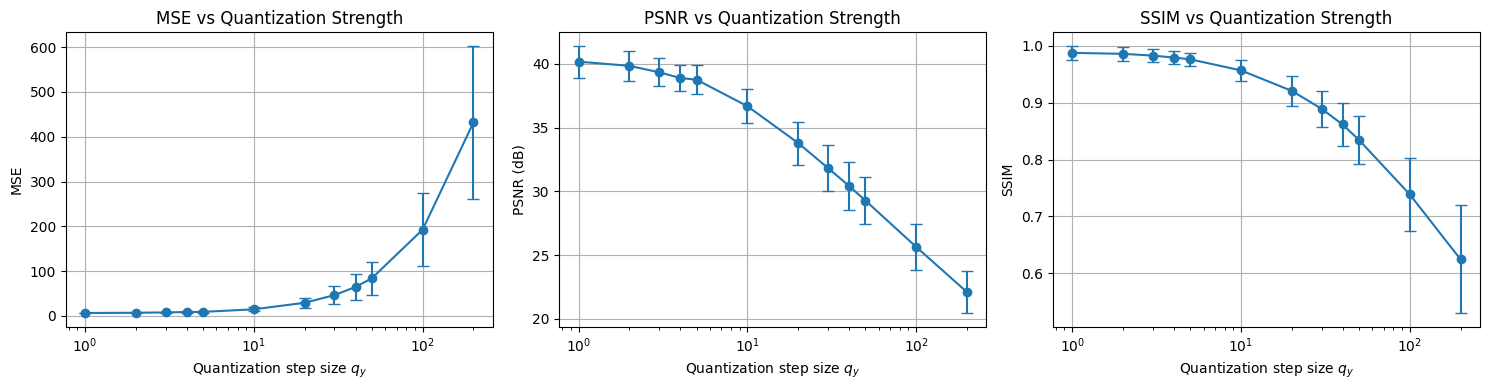

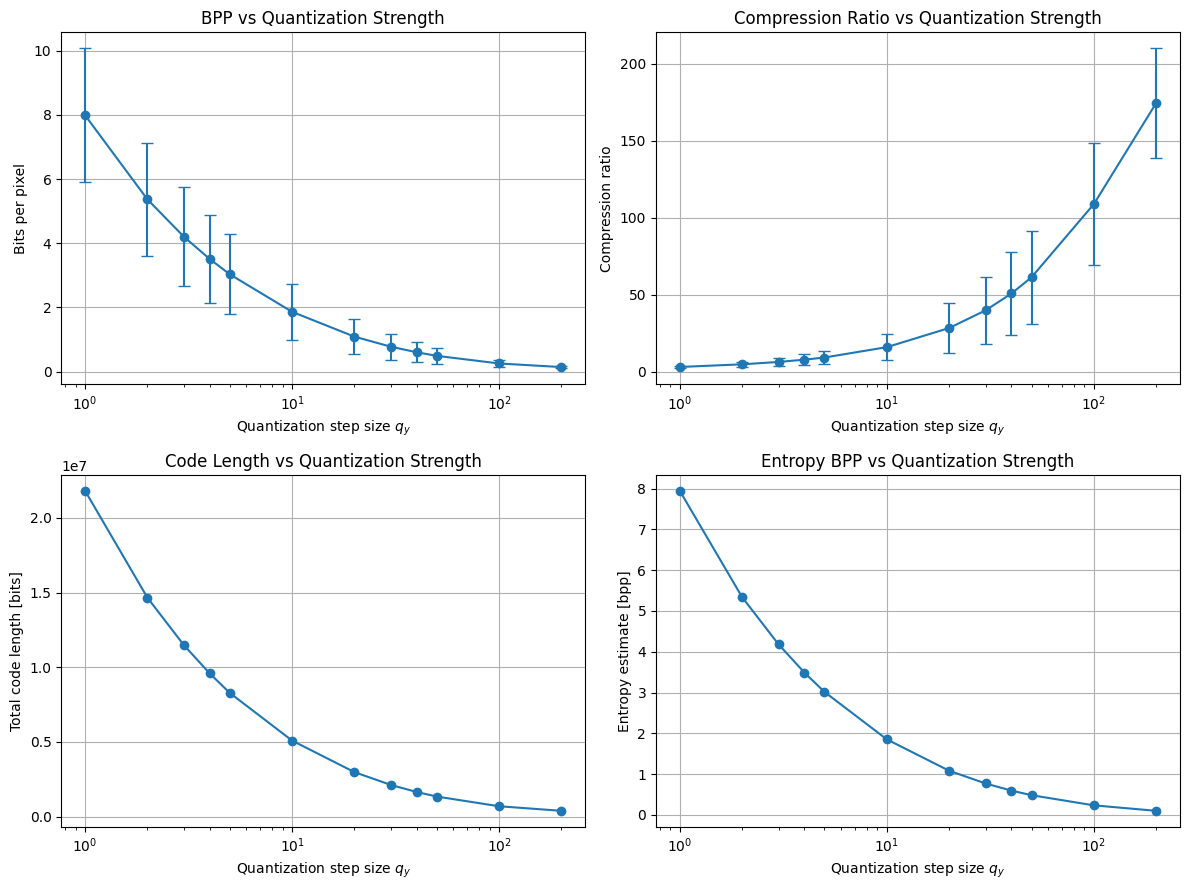

In [21]:
plot_reconstruction_quality(
    q_y_values,
    mse_mean, mse_std,
    psnr_mean, psnr_std,
    ssim_mean, ssim_std,
    save_path="reconstruction_quality_vs_q.png"
)

plot_compression_effect(
    q_y_values,
    bpp_mean, bpp_std,
    compression_ratio_mean, compression_ratio_std,
    L_total_bits_mean,
    entropy_bpp_mean,
    save_path="compression_effect_vs_q.png"
)

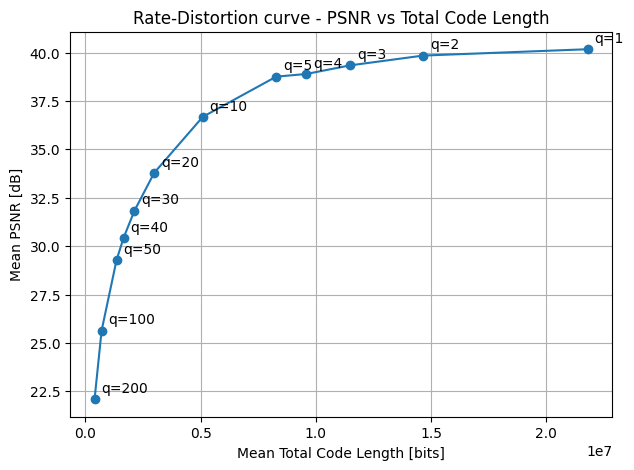

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(L_total_bits_mean, psnr_mean, marker="o")

for bpp, psnr, q in zip(L_total_bits_mean, psnr_mean, q_y_values):
    plt.annotate(f"q={q}", (bpp, psnr), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Mean Total Code Length [bits]")
plt.ylabel("Mean PSNR [dB]")
plt.title("Rate-Distortion curve - PSNR vs Total Code Length") 
plt.grid(True)

plt.show()

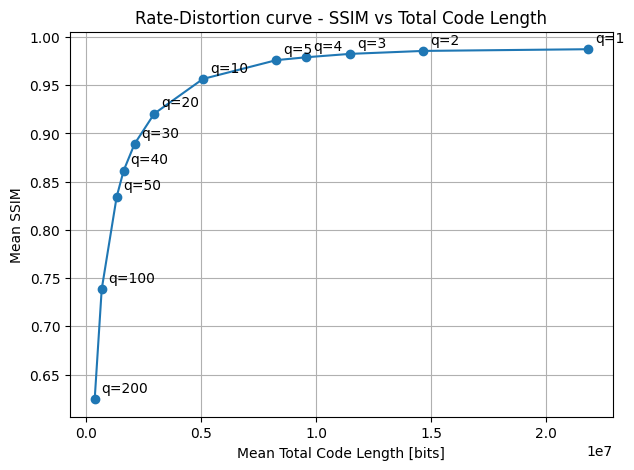

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(L_total_bits_mean, ssim_mean, marker="o")

for bpp, ssim, q in zip(L_total_bits_mean, ssim_mean, q_y_values):
    plt.annotate(f"q={q}", (bpp, ssim), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Mean Total Code Length [bits]")
plt.ylabel("Mean SSIM")
plt.title("Rate-Distortion curve - SSIM vs Total Code Length")
plt.grid(True)
plt.show()

In [33]:
q_y_values = [1,2,3,4,5,10,20,30,40,50,100, 200]

img = loaded_data_rgb[13]

mse_values = []
psnr_values = []
ssim_values = []
decoded_images = []
estimated_bpps = []

for q_y in q_y_values:
    codec = JPEGCodec(block_size=8, q_y=q_y, q_c=q_y*1.6)
    encoded = codec.encode(img)
    decoded = codec.decode(encoded)

    decoded_images.append(decoded)
    mse_values.append(MSE(img, decoded))
    psnr_values.append(PSNR(img, decoded))
    ssim_values.append(SSIM(img, decoded))

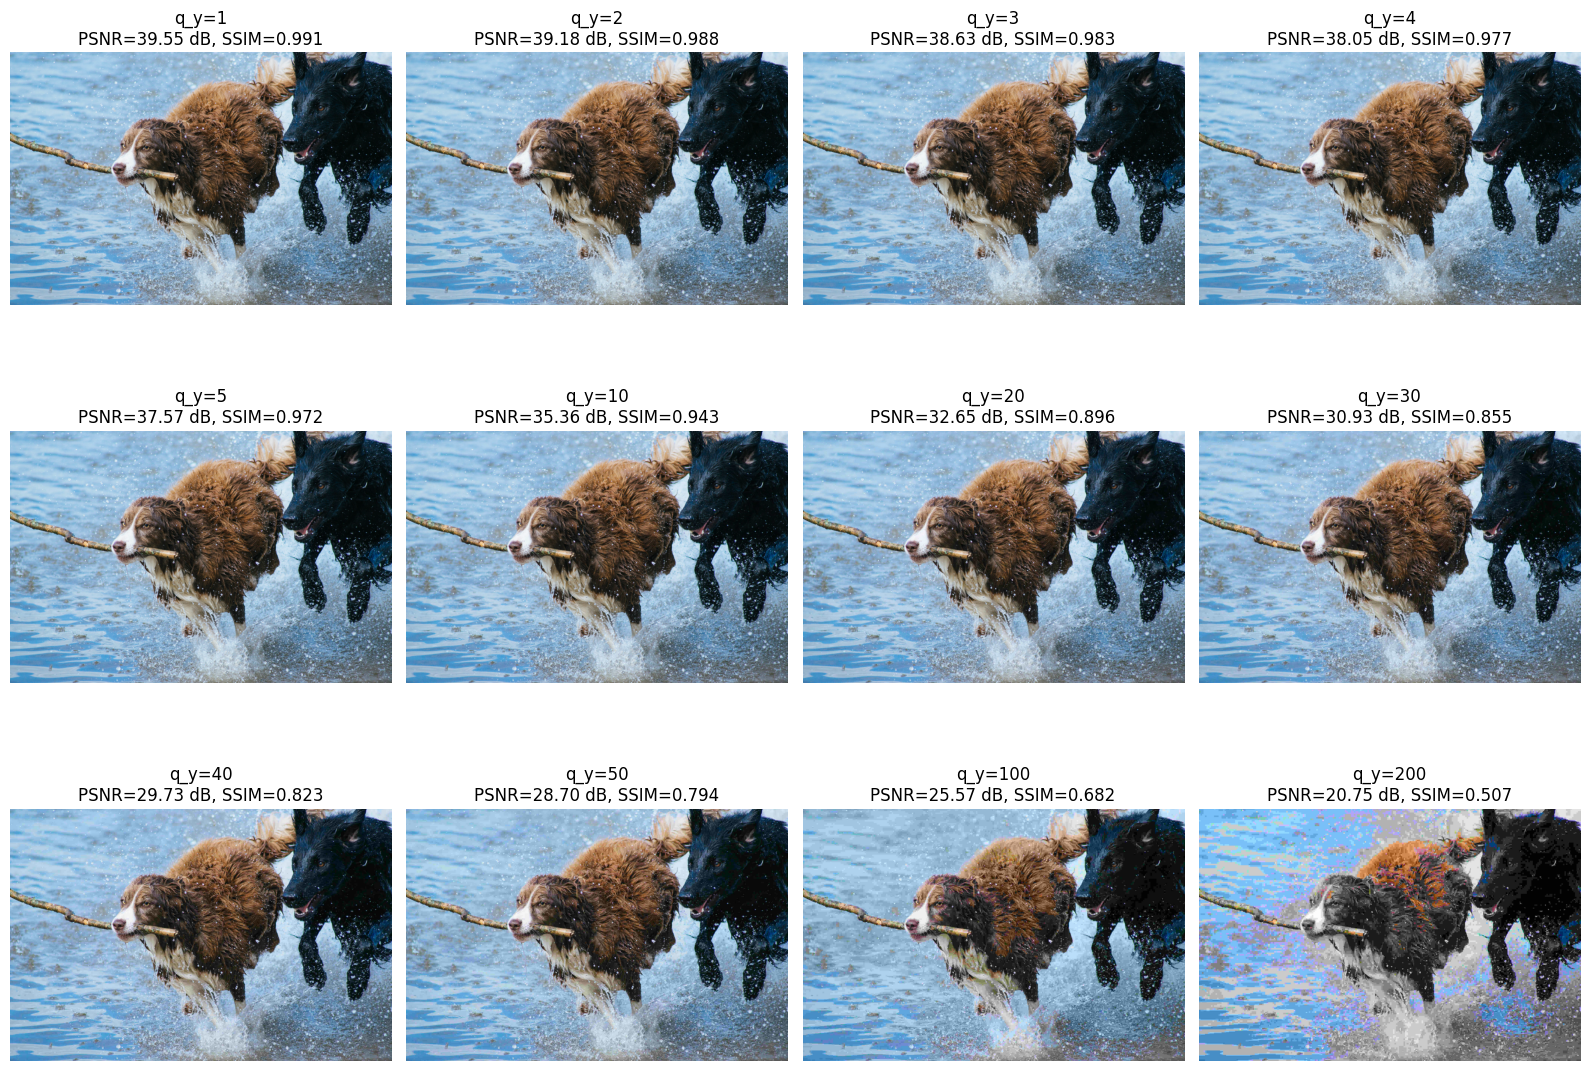

In [34]:
n = len(q_y_values)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(4 * cols, 4 * rows))

for i, (q_y, decoded, psnr, ssim) in enumerate(
    zip(q_y_values, decoded_images, psnr_values, ssim_values)
):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(decoded)
    plt.title(f"q_y={q_y}\nPSNR={psnr:.2f} dB, SSIM={ssim:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()